# Main2 - Stochastic Volatility Figure (Paper-style, 3 strategies)

This notebook creates one Figure-2-style plot under stochastic volatility to compare:
1. Delta-Gamma-Neutral
2. Delta-Vega-Neutral
3. RL (VaR95)

Default market setup follows paper section 4.4 style:
- `sigma0 = 0.30`
- `v = 0.30`
- `rho = -0.70`
- `kappa = 1%`
- one hedging option with maturity `T_hedge_days` (30 by default; set 90 to reproduce the other maturity case).



In [6]:
import os
import copy
import importlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from C_trading_environment import init_env
from G_parallel_evaluation import evaluate_policy_parallel
from H_parallel_training import train_jobs_parallel



In [7]:
# Reload core modules to avoid stale signatures in long-running kernels.
import A_market_model_greeks as _amg_mod
import B_MDP_state_generator as _bmsg_mod
import C_trading_environment as _env_mod
import G_parallel_evaluation as _gpe_mod
import H_parallel_training as _hpt_mod

_amg_mod = importlib.reload(_amg_mod)
_bmsg_mod = importlib.reload(_bmsg_mod)
_env_mod = importlib.reload(_env_mod)
_gpe_mod = importlib.reload(_gpe_mod)
_hpt_mod = importlib.reload(_hpt_mod)

evaluate_policy_parallel = _gpe_mod.evaluate_policy_parallel
train_jobs_parallel = _hpt_mod.train_jobs_parallel



In [8]:
def make_config_stoch(
    sigma0=0.30,
    v=0.30,
    rho=-0.70,
    kappa=0.01,
    T_hedge_days=30,
):
    return {
        "env": {
            "r": 0.0,
            "q": 0.0,
            "v": float(v),
            "rho": float(rho),
            "lambda_day": 1.0,
            "kappa": float(kappa),
            "contract_size": 100.0,
            "delta_hedge": True,
            "gamma_only_state": False,   # gamma + vega state for stochastic-vol setup
            "T_days": 30,
            "dt": 1 / 252,
            "T_client_days": 60,
            "T_hedge_days": int(T_hedge_days),
            "S0": 10.0,
            "sigma0": float(sigma0),
        },
        "model": {
            "state_dim": 5,
            "action_dim": 1,
            "M": 100,
            "hidden": 256,
            "n_layers": 3,
        },
        "train": {
            "buffer_capacity": 200_000,
            "batch_size": 256,
            "updates_per_step": 4,
            "gamma": 1.0,
            "tau_soft": 0.005,
            "alpha": 0.95,
            "lambda_std": 1.645,
            "k_huber": 1.0,
            "lr_actor": 1e-4,
            "lr_critic": 1e-4,
            "noise_std": 0.10,
            "warmup_steps": 1_000,
            "log_every": 0,
        },
    }


def plot_gain_distribution_stoch3(gain_samples_dict, title):
    names = list(gain_samples_dict.keys())
    colors = {
        "Delta-Gamma-Neutral": "tab:orange",
        "Delta-Vega-Neutral": "tab:blue",
        "RL (VaR95)": "tab:green",
    }

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(16, 7),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )

    all_vals = np.concatenate([np.asarray(gain_samples_dict[k], dtype=float) for k in names])
    x_min = float(np.min(all_vals)) - 5.0
    x_max = float(np.max(all_vals)) + 5.0
    x_grid = np.linspace(x_min, x_max, 900)

    for i, name in enumerate(names):
        g = np.asarray(gain_samples_dict[name], dtype=float)
        color = colors.get(name, None)

        if g.size > 1 and np.std(g) > 1e-12:
            kde = gaussian_kde(g)
            axes[0].plot(x_grid, kde(x_grid), label=name, color=color, lw=1.7)
        else:
            axes[0].axvline(float(np.mean(g)), label=name, color=color, lw=1.7)

        axes[1].plot(g, np.full_like(g, i, dtype=float), "|", color=color, markersize=8, alpha=0.9)

    axes[0].set_ylabel("density")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc="upper right")

    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names)
    axes[1].set_xlabel("gain")
    axes[1].grid(True, alpha=0.25)

    plt.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.show()



In [9]:
# ------------------------------
# Experiment controls
# ------------------------------
SEED_BASE = 321
N_EPISODES = 1000
N_EVAL = 5000

T_HEDGE_DAYS = 30   # set to 90 for the second maturity case from paper section 4.4

CONFIG_STOCH = make_config_stoch(
    sigma0=0.30,
    v=0.30,
    rho=-0.70,
    kappa=0.01,
    T_hedge_days=T_HEDGE_DAYS,
)

EVAL_MAX_WORKERS = max(1, (os.cpu_count() or 2) - 1)
TRAIN_MAX_WORKERS = 1

alpha_eval = float(CONFIG_STOCH["train"]["alpha"])
lambda_std_eval = float(CONFIG_STOCH["train"].get("lambda_std", 1.645))

eval_episode_seeds = [400_000 + ep for ep in range(N_EVAL)]

print(f"train episodes={N_EPISODES}, eval episodes={N_EVAL}, T_hedge={T_HEDGE_DAYS}d")
print(f"workers: train={TRAIN_MAX_WORKERS}, eval={EVAL_MAX_WORKERS}")



train episodes=1000, eval episodes=5000, T_hedge=30d
workers: train=1, eval=15


In [10]:
# ------------------------------
# Train RL (VaR95) policy for stochastic-vol setup
# ------------------------------

stoch_job = [{
    "job_id": f"stoch_var_T{T_HEDGE_DAYS}",
    "params": copy.deepcopy(CONFIG_STOCH),
    "objective": "var",
    "seed": SEED_BASE,
    "n_episodes": N_EPISODES,
    "meta": {"objective": "var", "setup": "stochastic_vol"},
}]

print("\n=== Training RL (VaR95) for stochastic-vol setup ===")
res_stoch = train_jobs_parallel(
    stoch_job,
    max_workers=TRAIN_MAX_WORKERS,
    show_progress=True,
    desc="Train Stoch RL(var)",
)

res_var = res_stoch[0]
trained_stoch_var = {
    "actor_state_dict": res_var["actor_state_dict"],
    "actor_kwargs": res_var["actor_kwargs"],
    "state_scale": np.asarray(res_var["state_scale"], dtype=np.float32),
    "history": res_var["history"],
}
print("Training done.")




=== Training RL (VaR95) for stochastic-vol setup ===


Train Stoch RL(var): 100%|██████████| 1/1 [1:49:31<00:00, 6571.36s/it]

Training done.


In [11]:
# ------------------------------
# Evaluate 3 strategies on identical seeds
# ------------------------------

env_params = CONFIG_STOCH["env"]

# Benchmark: Delta-Gamma-Neutral
m_dg, losses_dg = evaluate_policy_parallel(
    env_params=env_params,
    n_eval=N_EVAL,
    alpha=alpha_eval,
    lambda_std=lambda_std_eval,
    episode_seeds=eval_episode_seeds,
    benchmark_strategy="delta_gamma_neutral",
    max_workers=EVAL_MAX_WORKERS,
)

# Benchmark: Delta-Vega-Neutral
m_dv, losses_dv = evaluate_policy_parallel(
    env_params=env_params,
    n_eval=N_EVAL,
    alpha=alpha_eval,
    lambda_std=lambda_std_eval,
    episode_seeds=eval_episode_seeds,
    benchmark_strategy="delta_vega_neutral",
    max_workers=EVAL_MAX_WORKERS,
)

# RL (VaR95)
m_rl, losses_rl = evaluate_policy_parallel(
    env_params=env_params,
    n_eval=N_EVAL,
    alpha=alpha_eval,
    lambda_std=lambda_std_eval,
    episode_seeds=eval_episode_seeds,
    actor_state_dict=trained_stoch_var["actor_state_dict"],
    actor_kwargs=trained_stoch_var["actor_kwargs"],
    state_scale=trained_stoch_var["state_scale"],
    max_workers=EVAL_MAX_WORKERS,
)

print("\n--- Summary (loss metrics) ---")
print("Delta-Gamma-Neutral:", {"VaR95": float(m_dg["VaR"]), "mean": float(m_dg["mean"]), "mean_cost": float(m_dg["mean_cost"])})
print("Delta-Vega-Neutral :", {"VaR95": float(m_dv["VaR"]), "mean": float(m_dv["mean"]), "mean_cost": float(m_dv["mean_cost"])})
print("RL (VaR95)         :", {"VaR95": float(m_rl["VaR"]), "mean": float(m_rl["mean"]), "mean_cost": float(m_rl["mean_cost"]), "gamma_ratio": float(m_rl["gamma_hedge_ratio"]), "vega_ratio": float(m_rl["vega_hedge_ratio"])})




--- Summary (loss metrics) ---
Delta-Gamma-Neutral: {'VaR95': 22.479282769220013, 'mean': 6.753358942236975, 'mean_cost': 6.754685616560225}
Delta-Vega-Neutral : {'VaR95': 50.03294937802491, 'mean': 12.247885561700489, 'mean_cost': 12.486422749215158}
RL (VaR95)         : {'VaR95': 25.103693158053222, 'mean': 4.371458973796024, 'mean_cost': 4.608757481767514, 'gamma_ratio': 0.12002056052101451, 'vega_ratio': 0.19331222561629624}


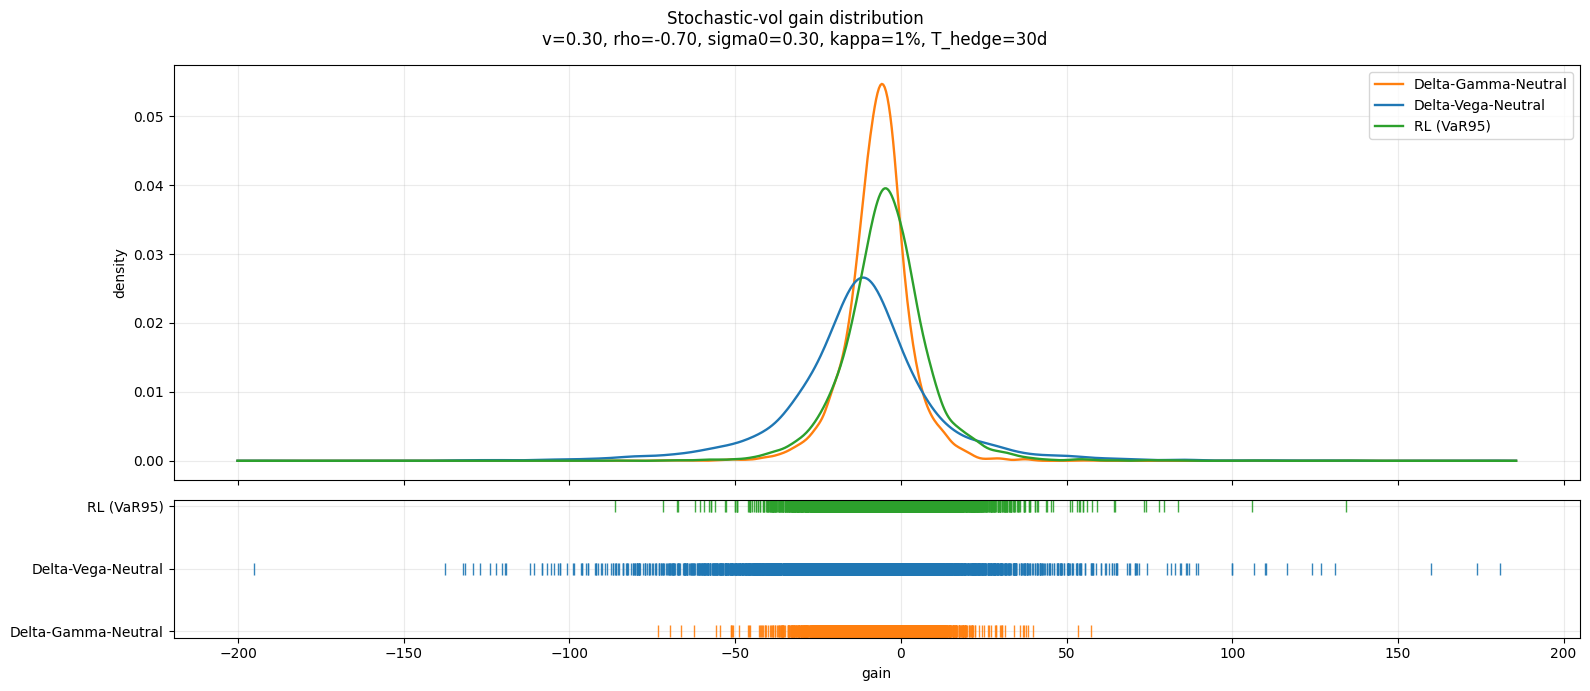

In [12]:
# ------------------------------
# Figure: stochastic-vol, 3 strategies
# ------------------------------

gain_samples = {
    "Delta-Gamma-Neutral": -np.asarray(losses_dg, dtype=float),
    "Delta-Vega-Neutral": -np.asarray(losses_dv, dtype=float),
    "RL (VaR95)": -np.asarray(losses_rl, dtype=float),
}

title = (
    "Stochastic-vol gain distribution\n"
    f"v=0.30, rho=-0.70, sigma0=0.30, kappa=1%, T_hedge={T_HEDGE_DAYS}d"
)
plot_gain_distribution_stoch3(gain_samples, title)

